In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
sns.set(style = 'whitegrid')

In [53]:
from google.colab import files
uploaded  = files.upload()

In [54]:
sentiment = pd.read_csv("fear_greed_index.csv")
trader = pd.read_csv("historical_data.csv")

In [55]:
print("Sentiment shape:", sentiment.shape)
print("Trader shape:", trader.shape)
print(sentiment.head())
print(trader.head())

Sentiment shape: (2644, 4)
Trader shape: (211224, 16)
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       B

In [56]:
sentiment['Date'] = pd.to_datetime(sentiment['date'])
trader['time'] = pd.to_datetime(trader['Timestamp IST'] , dayfirst=True)


In [57]:
daily_trader = trader.groupby(trader['time'].dt.date).agg({
    'Closed PnL': ['mean','sum' , 'std'],
    'Size USD': ['sum','mean']
}).reset_index()

daily_trader.columns = ['Date','avg_PnL','total_PnL','std_PnL','total_size','avg_size']

daily_trader['Date'] = pd.to_datetime(daily_trader['Date'])



In [58]:
sentiment['Date'] = pd.to_datetime(sentiment['Date'] , dayfirst=True)
sentiment_daily = sentiment.groupby('Date')['classification'].first().reset_index()

In [59]:
merged = pd.merge(daily_trader, sentiment_daily, on='Date', how='inner')

print(merged.head)
print(merged.info)

<bound method NDFrame.head of           Date    avg_PnL      total_PnL     std_PnL   total_size  \
0   2023-05-01   0.000000       0.000000    0.000000       477.00   
1   2023-12-05   0.000000       0.000000    0.000000     50005.83   
2   2023-12-14 -18.675885    -205.434737  179.663534    113203.35   
3   2023-12-15 -12.316017     -24.632034    4.474304     10609.95   
4   2023-12-16   0.000000       0.000000    0.000000     15348.77   
..         ...        ...            ...         ...          ...   
474 2025-04-27   8.018004    2702.067468   45.324840    487537.69   
475 2025-04-28  26.763462   36906.813759  381.983103  26124921.49   
476 2025-04-29  56.063136  125749.613427  420.736011  34089511.66   
477 2025-04-30  12.582028   14003.797269   64.654238  12693878.85   
478 2025-05-01  44.338886   54536.829297  972.822640  10720240.52   

         avg_size classification  
0      159.000000          Greed  
1     5556.203333  Extreme Greed  
2    10291.213636          Greed  
3

In [60]:
import os

os.makedirs("csv_files", exist_ok=True)

merged.to_csv("csv_files/merged_daily.csv" , index=False)

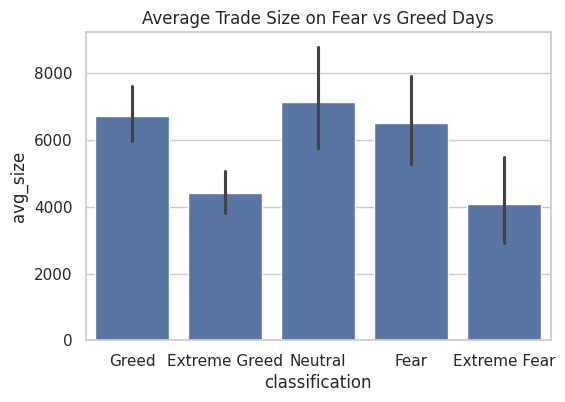

                   avg_size     std_PnL    total_size
classification                                       
Extreme Fear    4091.804366  729.867572  8.177447e+06
Extreme Greed   4410.524482  278.656985  1.091800e+06
Fear            6524.294937  351.688431  5.311261e+06
Greed           6735.295813  247.820567  1.495246e+06
Neutral         7157.527121  292.949624  2.690180e+06


In [61]:
plt.figure(figsize=(6,4))
sns.barplot(x = 'classification' , y = 'avg_size' , data = merged)
plt.title("Average Trade Size on Fear vs Greed Days")
plt.show()

print(merged.groupby("classification")[["avg_size" , "std_PnL" , "total_size"]].mean())

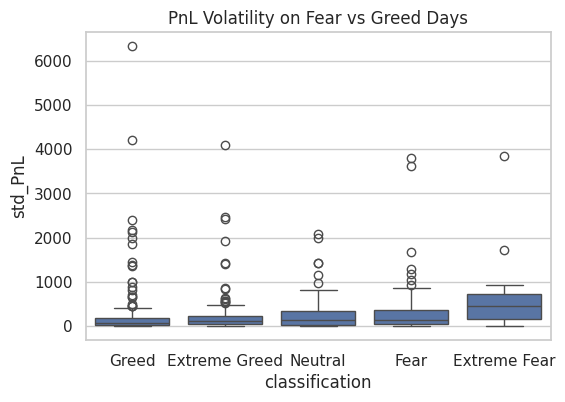

                   avg_size     std_PnL    total_size
classification                                       
Extreme Fear    4091.804366  729.867572  8.177447e+06
Extreme Greed   4410.524482  278.656985  1.091800e+06
Fear            6524.294937  351.688431  5.311261e+06
Greed           6735.295813  247.820567  1.495246e+06
Neutral         7157.527121  292.949624  2.690180e+06


In [62]:
plt.figure(figsize=(6,4))
sns.boxplot(x = 'classification' , y = 'std_PnL' , data = merged)
plt.title("PnL Volatility on Fear vs Greed Days")
plt.show()

print(merged.groupby("classification")[["avg_size" , "std_PnL" , "total_size"]].mean())

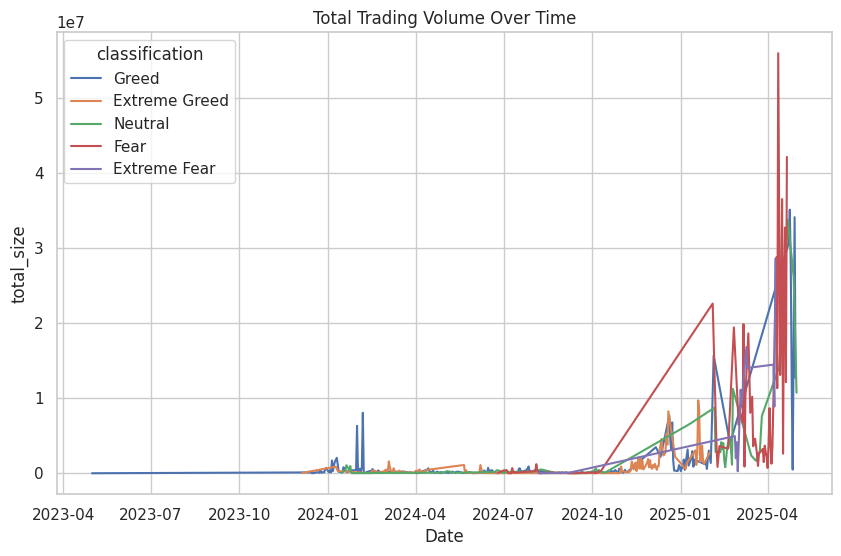

                   avg_size     std_PnL    total_size
classification                                       
Extreme Fear    4091.804366  729.867572  8.177447e+06
Extreme Greed   4410.524482  278.656985  1.091800e+06
Fear            6524.294937  351.688431  5.311261e+06
Greed           6735.295813  247.820567  1.495246e+06
Neutral         7157.527121  292.949624  2.690180e+06


In [64]:
plt.figure(figsize=(10,6))
sns.lineplot(x = 'Date' , y = 'total_size' , hue = 'classification' ,  data = merged)
plt.title("Total Trading Volume Over Time")
plt.show()

print(merged.groupby("classification")[["avg_size" , "std_PnL" , "total_size"]].mean())